In [1]:
import awkward as ak
import numpy as np
import uproot
import matplotlib.pyplot as plt 
from scipy.spatial import Delaunay
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch_geometric.data import Data, Dataset
import os
from torch_geometric.loader import DataLoader
from torch.utils.data import ConcatDataset
import glob
from torch_geometric.nn import GCNConv as gcn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch_geometric.nn import EdgeConv 
import csv
import sys
from torch_geometric.nn import global_mean_pool

In [30]:
data = torch.load("/home/wer2ct/ldmx_LLPnet/processed/test_signal_signal_5_graphs.pt", weights_only = False)

In [27]:
ecal_nodes = []
hcal_nodes = []
for d in data:
    ecal_nodes.append(d.num_nodes_ecal)
    hcal_nodes.append(d.num_nodes_hcal)

(array([4.1000e+01, 1.3970e+03, 8.3180e+03, 1.3457e+04, 1.2714e+04,
        4.0650e+03, 6.1500e+02, 1.0300e+02, 9.0000e+00, 3.0000e+00]),
 array([ 33. ,  39.7,  46.4,  53.1,  59.8,  66.5,  73.2,  79.9,  86.6,
         93.3, 100. ]),
 <BarContainer object of 10 artists>)

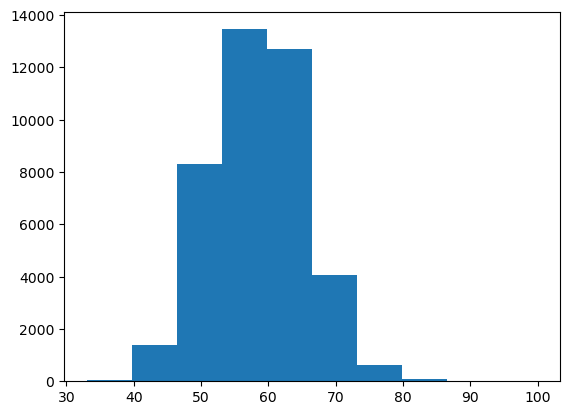

In [28]:
plt.hist(hcal_nodes)

In [12]:
data[348].det_idx

tensor([[0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]])

In [9]:
data[348].x

tensor([[-7.0711e-01,         nan, -1.0663e+00, -9.5707e-01],
        [ 1.4142e+00,         nan, -2.7136e-01, -4.2314e-01],
        [-7.0711e-01,         nan,  1.3377e+00,  1.3802e+00],
        [-2.5689e-01, -1.4261e+00, -1.6005e+00, -4.9087e-01],
        [-1.0204e-01,  1.8392e-01, -1.6005e+00,  1.1064e+00],
        [-1.4488e-01,  1.2573e+00, -1.6005e+00, -4.7540e-01],
        [-1.8673e+00,  3.2429e+00, -1.3294e+00, -4.9087e-01],
        [-6.4305e-01,  2.2777e-03, -1.3294e+00, -4.6975e-01],
        [-3.0922e-02,  7.5928e-02, -1.3294e+00,  1.3465e+00],
        [ 5.8121e-01,  1.7413e-01, -1.3294e+00, -4.8968e-01],
        [-3.4491e+00, -2.4995e+00, -1.0583e+00, -4.9087e-01],
        [-1.1249e+00, -1.4261e+00, -1.0583e+00, -4.7948e-01],
        [-9.7874e-01, -8.8944e-01, -1.0583e+00, -3.3596e-01],
        [-5.0279e-01, -3.5276e-01, -1.0583e+00, -3.9388e-01],
        [ 2.7514e-01,  1.8392e-01, -1.0583e+00,  6.1307e+00],
        [-6.3167e-01,  7.2059e-01, -1.0583e+00, -4.3125e-01],
        

In [10]:
npz = np.load("/standard/ldmxuva/gnn_files/note_stuff/training_npz/signal/signal_batch2_train_filtered_signal_5.npz")

In [20]:
ecal_arr = npz['ecal_hits_array']
ecal_arr[ecal_arr[:,0] == 2.0] 

array([], shape=(0, 5), dtype=float64)

In [19]:
ecal_arr

array([[ 0.00000000e+00,  4.81586409e+00, -2.50239639e+01,
         2.47582001e+02,  2.07470608e+00],
       [ 0.00000000e+00,  2.40793204e+00, -2.08533020e+01,
         2.56062012e+02,  3.53492093e+00],
       [ 0.00000000e+00,  4.81586409e+00, -1.66826420e+01,
         2.73226013e+02,  5.24028873e+00],
       ...,
       [ 5.99980000e+04, -1.92634563e+01,  2.50239639e+01,
         5.53302002e+02,  3.14512253e+01],
       [ 5.99980000e+04,  9.44461746e+01,  8.34132099e+00,
         5.53302002e+02,  2.15499134e+01],
       [ 5.99980000e+04,  3.88031173e+00,  1.15158073e+02,
         6.05710022e+02,  1.57513990e+01]], shape=(1620511, 5))

In [6]:
#Training Stuff
SEED = 2026
np.random.seed(SEED)    # Setting the seed for reproducibility
torch.manual_seed(SEED)
#signal_directory = '/standard/ldmxuva/gnn_files/note_stuff/training_graphs/signal/processed'
#dimuon_directory = '/standard/ldmxuva/gnn_files/note_stuff/training_graphs/dimuon/processed'
enriched_directory = '/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed'

#Path to our batches
#signal_file_paths = glob.glob(os.path.join(signal_directory, "training*"))
#dimuon_file_paths = glob.glob(os.path.join(dimuon_directory, "training*"))
enriched_file_paths = glob.glob(os.path.join(enriched_directory, "training*"))

#signal_training_list = []
#dimuon_training_list = []
enriched_training_list = []

In [7]:
for i, path in enumerate(enriched_file_paths):
    enriched_training_list.append(torch.load(path, weights_only = False))
    if (i % 10 == 0) :
        print(path)

/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4147_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4464_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4817_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4318_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4376_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4852_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4174_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/enriched/processed/training_enriched_background_4847_graphs.pt
/standard/ldmxuva/gnn_files/note_stuff/training_graphs/e

In [8]:
torch.save(enriched_training_list, "/standard/ldmxuva/gnn_files/note_stuff/training_graphs_all/training_enriched_merged.pt")